In [5]:
import scipy
import numpy as np

In [6]:
def boiler_heat_output(qin_boiler):
    qout_nom_boiler = 530.0
    eta_nom_boiler = 0.8
    lambda_in_min_boiler = 0.173
    lambda_out_min_boiler = 0.2
    beta_boiler = (1.0 - lambda_in_min_boiler) / (1.0 - lambda_out_min_boiler)
    qin_min_boiler = lambda_in_min_boiler * qout_nom_boiler / eta_nom_boiler
    qin_max_boiler = qout_nom_boiler / eta_nom_boiler

    if qin_boiler <= 0.0:
        return 0.0
    if qin_boiler < qin_min_boiler:
        return 0.0
    if qin_boiler > qin_max_boiler:
        qin_boiler = qin_max_boiler

    return qout_nom_boiler * (
        lambda_out_min_boiler
        + (1.0 / beta_boiler) * (qin_boiler * eta_nom_boiler / qout_nom_boiler - lambda_in_min_boiler)
    )


def chp_heat_output(qin_chp):
    qout_nom_chp = 470.0
    eta_nom_chp_th = 0.481
    lambda_in_min_chp = 0.582
    lambda_out_min_chp_th = 0.622
    beta_chp_th = (1.0 - lambda_in_min_chp) / (1.0 - lambda_out_min_chp_th)
    qin_min_chp = lambda_in_min_chp * qout_nom_chp / eta_nom_chp_th
    qin_max_chp = qout_nom_chp / eta_nom_chp_th

    if qin_chp <= 0.0:
        return 0.0
    if qin_chp < qin_min_chp:
        return 0.0
    if qin_chp > qin_max_chp:
        qin_chp = qin_max_chp

    return qout_nom_chp * (
        lambda_out_min_chp_th
        + (1.0 / beta_chp_th) * (qin_chp * eta_nom_chp_th / qout_nom_chp - lambda_in_min_chp)
    )


def chp_electricity_output(qin_chp):
    pout_nom_chp = 380.0
    eta_nom_chp_el = 0.389
    lambda_in_min_chp = 0.582
    lambda_out_min_chp_el = 0.5
    beta_chp_el = (1.0 - lambda_in_min_chp) / (1.0 - lambda_out_min_chp_el)
    qin_min_chp = lambda_in_min_chp * pout_nom_chp / eta_nom_chp_el
    qin_max_chp = 470.0 / 0.481

    if qin_chp <= 0.0:
        return 0.0
    if qin_chp < qin_min_chp:
        return 0.0
    if qin_chp > qin_max_chp:
        qin_chp = qin_max_chp

    return pout_nom_chp * (
        lambda_out_min_chp_el
        + (1.0 / beta_chp_el) * (qin_chp * eta_nom_chp_el / pout_nom_chp - lambda_in_min_chp)
    )


Maximum inputs: 
Boiler: 662.50
CHP: 977.13
Boiler heat linearization:        OUT = 0.8078 * IN   (MSE=540.8437)
CHP heat linearization:           OUT = 0.3948 * IN   (MSE=12215.2754)
CHP electricity linearization:    OUT = 0.2980 * IN   (MSE=7000.6649)


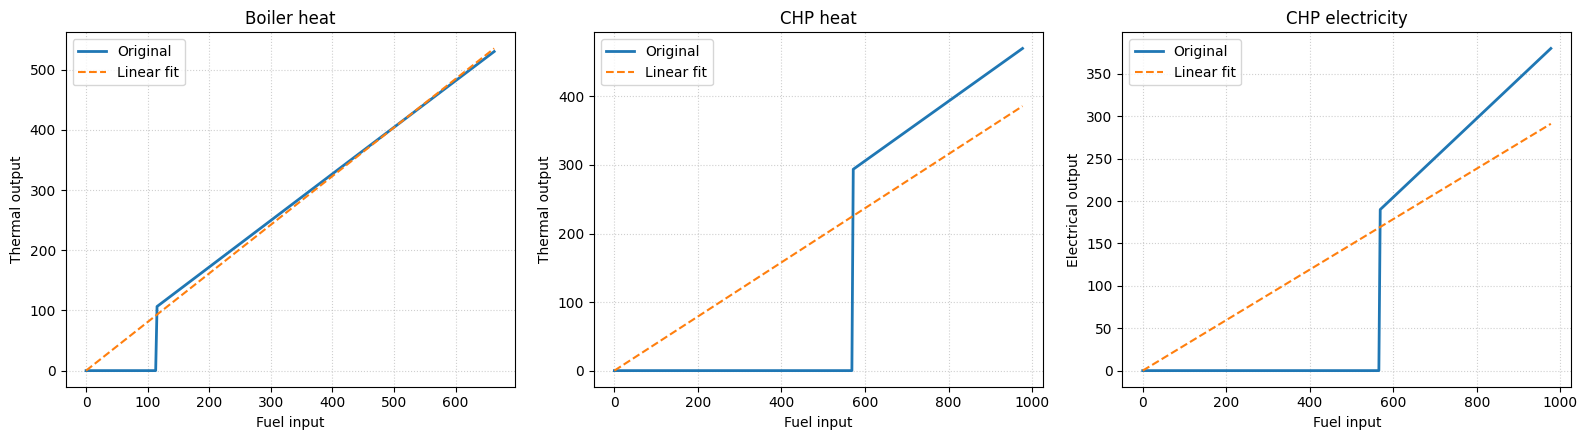

In [9]:
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt


def fit_linear_slope_through_origin(nonlinear_func, x_max, num_samples=400):
    x_values = np.linspace(0.0, x_max, num_samples)
    y_values = np.array([nonlinear_func(x) for x in x_values], dtype=float)

    def objective(m):
        y_linear = m * x_values
        return np.mean((y_linear - y_values) ** 2)

    result = minimize_scalar(objective, bounds=(0.0, 10.0), method="bounded")
    return result.x, result.fun


boiler_x_max = 530.0 / 0.8
chp_x_max = 470.0 / 0.481

print("Maximum inputs: ")
print(f"Boiler: {boiler_x_max:.2f}")
print(f"CHP: {chp_x_max:.2f}")

m_boiler_heat, err_boiler_heat = fit_linear_slope_through_origin(boiler_heat_output, boiler_x_max)
m_chp_heat, err_chp_heat = fit_linear_slope_through_origin(chp_heat_output, chp_x_max)
m_chp_el, err_chp_el = fit_linear_slope_through_origin(chp_electricity_output, chp_x_max)

print(f"Boiler heat linearization:        OUT = {m_boiler_heat:.4f} * IN   (MSE={err_boiler_heat:.4f})")
print(f"CHP heat linearization:           OUT = {m_chp_heat:.4f} * IN   (MSE={err_chp_heat:.4f})")
print(f"CHP electricity linearization:    OUT = {m_chp_el:.4f} * IN   (MSE={err_chp_el:.4f})")

x_boiler = np.linspace(0.0, boiler_x_max, 300)
x_chp = np.linspace(0.0, chp_x_max, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=False)

axes[0].plot(x_boiler, [boiler_heat_output(x) for x in x_boiler], label="Original", linewidth=2)
axes[0].plot(x_boiler, m_boiler_heat * x_boiler, label="Linear fit", linestyle="--")
axes[0].set_title("Boiler heat")
axes[0].set_xlabel("Fuel input")
axes[0].set_ylabel("Thermal output")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

axes[1].plot(x_chp, [chp_heat_output(x) for x in x_chp], label="Original", linewidth=2)
axes[1].plot(x_chp, m_chp_heat * x_chp, label="Linear fit", linestyle="--")
axes[1].set_title("CHP heat")
axes[1].set_xlabel("Fuel input")
axes[1].set_ylabel("Thermal output")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

axes[2].plot(x_chp, [chp_electricity_output(x) for x in x_chp], label="Original", linewidth=2)
axes[2].plot(x_chp, m_chp_el * x_chp, label="Linear fit", linestyle="--")
axes[2].set_title("CHP electricity")
axes[2].set_xlabel("Fuel input")
axes[2].set_ylabel("Electrical output")
axes[2].grid(True, linestyle=":", alpha=0.6)
axes[2].legend()

fig.tight_layout()
plt.show()
fig.savefig("linearization_plots.png", dpi=300)